# OmniCare Clinical Analytics — Multicollinearity Forensics and Prediction Engine

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
import missingno as msno
import category_encoders as ce


---
## Phase 1: Causal Topology and Multicollinearity Forensics

### Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)

The beta AI model found a statistically significant positive correlation between Inpatient_Admission_Rate and High_Deductible_Insurance_Plan. The marketing team wants to publish a white paper claiming that high-deductible plans cause patients to require more inpatient care due to delayed preventative treatment.

Poverty is the omitted confounder driving both variables simultaneously. Low-income patients are more likely to enroll in high-deductible plans (because premiums are lower, and that is what they can afford), and they are independently more likely to be admitted as inpatients (because of worse baseline health, limited access to preventative care, food insecurity, environmental stressors, etc.). The correlation between insurance type and admission rate is real, but the causal arrow does not run between them. It runs from poverty to both.

Regressing Inpatient_Admission_Rate on High_Deductible_Insurance_Plan without controlling for poverty produces a biased coefficient because OLS cannot distinguish the direct effect of the insurance plan from the backdoor path flowing through the confounder. The estimated beta hat on insurance type absorbs the entire poverty channel, inflating the coefficient far beyond any genuine causal effect. The predictive weight is mathematically contaminated: it captures association along the non-causal backdoor path, and the marketing team's white paper would be attributing to insurance design what is actually driven by socioeconomic structure.

### Step 1.2: The Variance Inflation Factor (VIF) Audit

In [17]:
# Step 1.2: Load vitals data and compute VIF
vitals = pd.read_csv('../Data/OmniCare_Clinical_Vitals.csv')
print(f"Vitals dataset: {vitals.shape[0]} patients × {vitals.shape[1]} columns")
print(vitals.head())

features = ['Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP']
X = vitals[features]
X_const = sm.add_constant(X)

vif_df = pd.DataFrame({
    'Feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})
# Drop the constant row for cleaner display
vif_df = vif_df[vif_df['Feature'] != 'const'].reset_index(drop=True)

print("VIF Audit (All Features)")
print(vif_df.to_string(index=False))
print("Features exceeding VIF > 10.0:")
flagged = vif_df[vif_df['VIF'] > 10.0]
print(flagged.to_string(index=False))

Vitals dataset: 5000 patients × 6 columns
   Patient_ID  Height_cm  Weight_kg    BMI  Systolic_BP  Diastolic_BP
0        1000      177.5       66.3  21.06        110.0          75.0
1        1001      167.9       57.5  20.39        115.0          79.0
2        1002      179.7       57.4  17.77        111.0          77.0
3        1003      192.8       80.9  21.76        122.0          88.0
4        1004      166.5       65.7  23.70        138.0          89.0
VIF Audit (All Features)
     Feature       VIF
   Height_cm 28.419446
   Weight_kg 57.428058
         BMI 16.981232
 Systolic_BP  4.219406
Diastolic_BP  4.219820
Features exceeding VIF > 10.0:
  Feature       VIF
Height_cm 28.419446
Weight_kg 57.428058
      BMI 16.981232


BMI, Height_cm, and Weight_kg all exceed the VIF threshold of 10.0. This is not surprising: BMI is a deterministic function of height and weight, so including all three in a regression is algebraically redundant. The most natural variable to drop is BMI, since it is entirely derived from the other two and carries no independent physiological information.

In [21]:
# Step 1.2 (cont.): Drop BMI and recalculate VIF
sanitized_features = ['Height_cm', 'Weight_kg', 'Systolic_BP', 'Diastolic_BP']
X_sanitized = vitals[sanitized_features]
X_sanitized_const = sm.add_constant(X_sanitized)

vif_sanitized = pd.DataFrame({
    'Feature': X_sanitized_const.columns,
    'VIF': [variance_inflation_factor(X_sanitized_const.values, i)
            for i in range(X_sanitized_const.shape[1])]
})
vif_sanitized = vif_sanitized[vif_sanitized['Feature'] != 'const'].reset_index(drop=True)

print("VIF Audit (After Dropping BMI)")
print(vif_sanitized.to_string(index=False))
print("All VIFs below 10.0")

VIF Audit (After Dropping BMI)
     Feature      VIF
   Height_cm 3.763812
   Weight_kg 3.763969
 Systolic_BP 4.219406
Diastolic_BP 4.219820
All VIFs below 10.0


---
## Phase 2: Visual Forensics and The High-Cardinality Frontier

### Step 2.1: The Architecture of Missingness

Load the telemetry dataset from remote patient monitoring wearables and generate a missingness matrix to identify structural gaps in the data.

Telemetry dataset: 5000 patients × 8 columns
Missing values per column:
Patient_ID                           0
High_Deductible_Insurance_Plan       0
Inpatient_Admission_Rate             0
Continuous_Heart_Rate             1214
Primary_Diagnosis_Code               0
Clinic_Capacity_Percentage           0
Time_of_Day_Index                    0
Procedure_Cost_USD                   0
dtype: int64


/var/folders/jf/x2sw3ygx6ngby4kp8fyjv01w0000gn/T/ipykernel_34651/2506062091.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


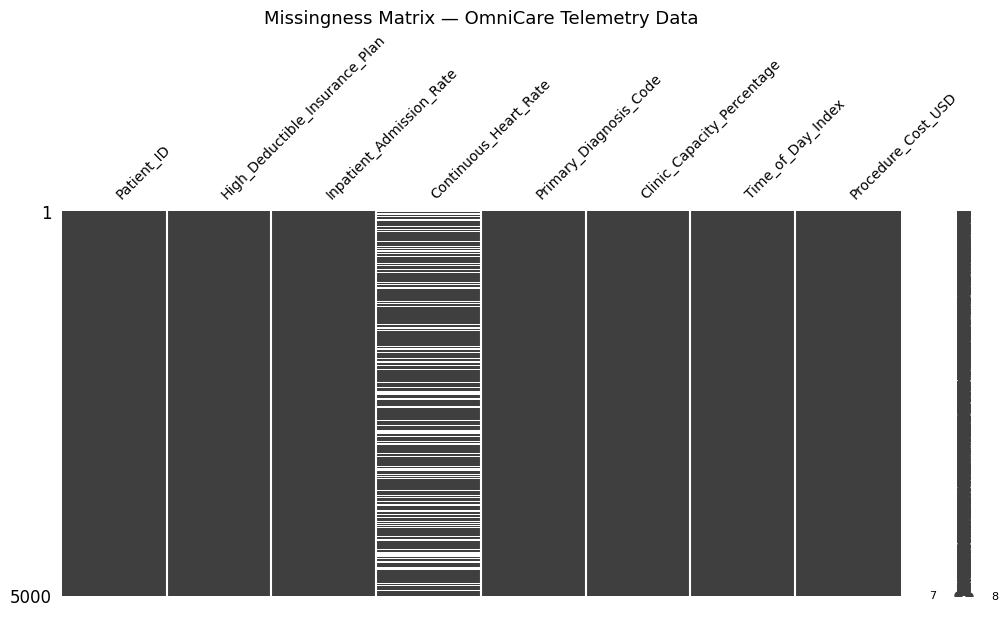

In [27]:
# Step 2.1: Load telemetry data and visualize missingness
telemetry = pd.read_csv('../Data/OmniCare_Telemetry_Data.csv')
print(f"Telemetry dataset: {telemetry.shape[0]} patients × {telemetry.shape[1]} columns")
print("Missing values per column:")
print(telemetry.isnull().sum())

# Missingness matrix
msno.matrix(telemetry, figsize=(12, 5), fontsize=10)
plt.title('Missingness Matrix — OmniCare Telemetry Data', fontsize=13)
plt.tight_layout()
plt.show()

**Analysis: Rubin's Taxonomy**

The missingness matrix confirms significant gaps in Continuous_Heart_Rate. If these gaps occur because low-income patients systematically refuse to transmit telemetry due to the data-plan costs of continuous streaming, this is MNAR. The probability of the value being missing depends on the unobserved value itself: patients with the least consistent heart rate monitoring are precisely the patients whose health outcomes we most need to track, and the missingness mechanism is driven by a variable (income/ability to pay for data transmission) that is directly related to the health outcomes the heart rate data is meant to capture.

This cannot be MAR, because MAR requires that the missingness is fully explained by other observed variables in the dataset. Here, the causal driver of missingness (inability to afford continuous data streaming) is not recorded in the telemetry table. And it is certainly not MCAR: the gaps are not randomly scattered across the patient population but are concentrated among a specific socioeconomic subgroup.

Mean imputation would destroy the dataset's integrity because it would replace the missing values with the average heart rate of patients who could afford continuous streaming, which is a systematically healthier, wealthier subgroup. The imputed values would be drawn from the wrong distribution entirely, artificially compressing variance and biasing any downstream model toward the health profile of higher-income patients. The result is a dataset that looks complete but silently encodes the assumption that poor patients have the same heart rate distribution as wealthy ones.

### Step 2.2: Escaping the Dummy Variable Trap

The dataset contains a categorical column, Primary_Diagnosis_Code, with hundreds of distinct ICD-10 strings.

**The Trap:** If a junior analyst runs pd.get_dummies() on this column, it generates one binary column per category. With $k$ categories and a constant intercept term, the design matrix X now contains $k + 1$ columns where one is a perfect linear combination of the others: for every observation, the $k$ dummy columns sum to exactly 1, which is identical to the intercept column. This means $\mathbf{X}^T\mathbf{X}$ is singular (its determinant is zero), and the OLS estimator Beta hat = $(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ requires inverting a matrix that has no inverse. The system of normal equations has infinitely many solutions because the columns are linearly dependent. OLS cannot uniquely identify the coefficient on each dummy when one dummy is a perfect linear function of the rest plus the intercept. The estimator thus becomes mathematically undefined.

### Step 2.3: Target Encoding Implementation

To prevent the Curse of Dimensionality and computational failure, utilize the category_encoders library. Apply a TargetEncoder to the Primary_Diagnosis_Code column, mathematically mapping the high-cardinality strings to the continuous historical mean of the target variable (Procedure_Cost_USD).

In [34]:
# Step 2.3: Target Encoding with category_encoders
encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])
telemetry['Target_Encoded_Diagnosis'] = encoder.fit_transform(
    telemetry['Primary_Diagnosis_Code'], telemetry['Procedure_Cost_USD']
)

print(telemetry[['Primary_Diagnosis_Code', 'Target_Encoded_Diagnosis']].head())

  Primary_Diagnosis_Code  Target_Encoded_Diagnosis
0                J86.381               1707.697108
1                M29.789               1792.303198
2                E49.618               1730.334968
3                E66.244               1725.060944
4                J45.553               1801.821085


---
## Phase 3: Architecting the Prediction Engine

### Step 3.1: OLS Optimization via Patsy Formulas
Merge the sanitized features into a final analytical dataframe. Utilize statsmodels.formula.api (specifically the smf.ols function) to define an R-style formula string regressing Procedure_Cost_USD onto your Target_Encoded_Diagnosis, Clinic_Capacity_Percentage, Time_of_Day_Index, and the sanitized vital signs from Phase 1.

In [36]:
# Step 3.1: Merge datasets and fit OLS
vitals_clean = vitals.drop(columns=['BMI'])
df = pd.merge(vitals_clean, telemetry, on='Patient_ID')

print(f"Columns: {list(df.columns)}")

# OLS via Patsy formula
formula = ('Procedure_Cost_USD ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage '
           '+ Time_of_Day_Index + Height_cm + Weight_kg + Systolic_BP + Diastolic_BP')

model = smf.ols(formula, data=df).fit()
print(model.summary())

Columns: ['Patient_ID', 'Height_cm', 'Weight_kg', 'Systolic_BP', 'Diastolic_BP', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Primary_Diagnosis_Code', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD', 'Target_Encoded_Diagnosis']
                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          6.83e-296
Time:                        12:00:38   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                    

### Step 3.2: Financial Loss Quantification (RMSE)

The executive board requires risk quantification in absolute US Dollars. Utilize the statsmodels.tools.eval_measures.rmse function to calculate the Root Mean Squared Error of the fitted predictions against the ground truth.

In [44]:
# Step 3.2: Compute RMSE in USD
fitted_values = model.fittedvalues
actual_values = df['Procedure_Cost_USD']
model_rmse = rmse(actual_values, fitted_values)

print(f"RMSE: ${model_rmse:.2f}")
print(f"R-squared: {model.rsquared:.3f}")

RMSE: $334.80
R-squared: 0.243


**Analysis: Financial Loss Quantification**

If a typical outpatient MRI costs $1,200 and the model generates an RMSE of $450, the algorithm's average prediction error is 37.5% of the procedure's actual cost. This carries catastrophic operational, financial, and regulatory risks:

Operational risk: a hospital dynamically pricing procedures based on predictions that swing $450 in either direction will systematically misprice a large share of its services. Underpredictions mean the hospital absorbs losses on procedures it could not accurately cost. Overpredictions mean patients are billed hundreds of dollars above fair value.

Financial risk: at scale, a $450 average error across thousands of daily procedures compounds into millions of dollars of misallocated revenue. Budgeting, staffing, and resource allocation decisions built on these predictions would be anchored to noise rather than signal.

Regulatory risk: healthcare pricing is subject to federal and state transparency mandates. An algorithm that routinely misprices procedures by 37.5% invites regulatory scrutiny, potential violations of price transparency rules, and legal liability if patients can demonstrate they were systematically overcharged by a black-box model. 

### Step 3.3: Residual Diagnostics for Heteroscedasticity

An OLS model relies on the absolute assumption of homoscedasticity (constant variance of residual errors). Extract the fitted values and the residuals from your statsmodels object. Utilize seaborn.scatterplot to map the residuals on the Y-axis against the fitted values on the X-axis.

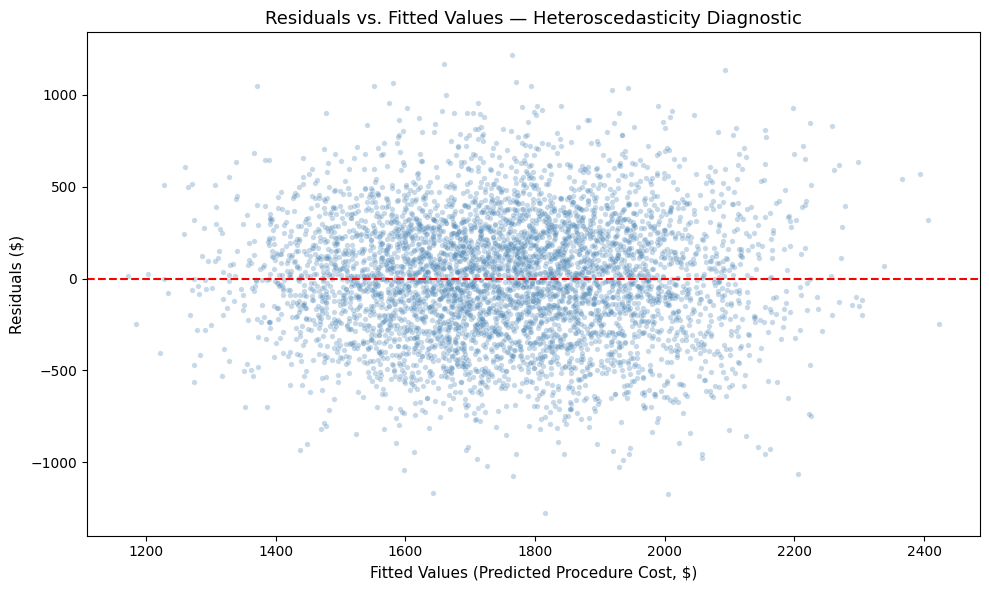

In [48]:
# Step 3.3: Residual vs. Fitted Values plot
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted, y=residuals, alpha=0.3, s=15, color='steelblue')
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Fitted Values (Predicted Procedure Cost, $)', fontsize=11)
plt.ylabel('Residuals ($)', fontsize=11)
plt.title('Residuals vs. Fitted Values — Heteroscedasticity Diagnostic', fontsize=13)
plt.tight_layout()
plt.show()

**Analysis: Residual Diagnostics for Heteroskedasticity**

The residual scatter plot does not exhibit the classic fan shape. The vertical spread of residuals remains roughly constant (approximately $\pm$1,000) across the full range of fitted values from $1,100 to $2,500. The cloud is not wider on the right than on the left. This is good news for the homoscedasticity assumption, but it does not make the model safe to deploy. The residuals are centered on zero (the model is not systematically biased in one direction), yet the sheer magnitude of the spread is the problem. The algorithm routinely misses by $500 to $1,000 in either direction regardless of the predicted cost level. That is not heteroscedasticity; it is uniformly poor precision. The model is equally unreliable at every pricing tier, which means the structural flaw is not that errors grow at peak surge-pricing levels but that the errors are unacceptably large everywhere. A hospital deploying this algorithm would face a flat, constant risk of substantial misprediction across the board.

**Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)**

As a modern Tech Economist, you must command AI agents to accelerate your workflow. Utilize the P.R.I.M.E. Prompting Framework (Persona, Role, Instructions, Meaning, Evaluation) to orchestrate an LLM (ChatGPT or Claude) to generate advanced statistical tests.

**Prompt**
  
  [Prep] Act as an expert Python Data Scientist specializing in econometrics and OLS regression diagnostics.                                                                                                               
                                                                                                                                                                                                                           
  [Request] I just completed an assignment where I built an OLS regression model using statsmodels.formula.api (smf.ols) to predict Procedure_Cost_USD from target-encoded diagnosis codes, clinic capacity, time of day,  
  and four physiological vital signs (Height_cm, Weight_kg, Systolic_BP, Diastolic_BP). I visually inspected a residuals vs. fitted values scatterplot for heteroscedasticity. Now, I want to formally test for            
  heteroscedasticity using White's Lagrange Multiplier Test. Please write the Python code to execute this test on my existing fitted OLS model object (named model) and print the LM test statistic, the p-value, and a
  concluding sentence stating whether the null hypothesis of homoscedasticity is rejected at the 5% significance level.                                                                                                    
                                                            
  [Iterate] Ensure the code uses statsmodels.stats.diagnostic.het_white and passes the residuals and the exogenous variables from my existing model object. Do not refit the regression. Do not use any libraries beyond   
  statsmodels and numpy. Keep the output clean and interpretable for a non-technical executive audience.
                                                                                                                                                                                                                           
  [Mechanism Check] Add inline comments explaining exactly what the het_white function takes as inputs, what the null hypothesis of the LM test is, and how the test statistic and p-value are derived from the auxiliary  
  regression of squared residuals on the original regressors and their cross-products.
                                                                                                                                                                                                                           
  [Evaluate] Provide a brief explanation of how I should interpret the p-value in the context of my OLS model's reliability, specifically whether the standard errors and t-statistics from the original regression summary
   can be trusted or whether robust standard errors (HC3) are needed.

### Task 4.1: White's Lagrange Multiplier Test for Heteroscedasticity (AI-Generated Code)

In [49]:
# ============================================================
# White's Lagrange Multiplier Test for Heteroscedasticity
# ============================================================
from statsmodels.stats.diagnostic import het_white

# het_white takes two inputs:
#   1. resid: the OLS residuals (model.resid)
#   2. exog:  the exogenous (independent) variables INCLUDING the constant
#             (model.model.exog pulls the design matrix from the fitted model)
#
# Null hypothesis (H0): The residual variance is constant across all
# observations (homoscedasticity). The errors are identically distributed.
#
# The test works by running an auxiliary regression of the squared residuals
# on the original regressors, their squares, and all pairwise cross-products.
# The LM test statistic = n * R² from this auxiliary regression, and it
# follows a chi-squared distribution. A large test statistic (small p-value)
# means the squared residuals are systematically related to the regressors,
# which rejects homoscedasticity.

lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(model.resid, model.model.exog)

print("=" * 50)
print("WHITE'S LAGRANGE MULTIPLIER TEST")
print("=" * 50)
print(f"LM Test Statistic: {lm_stat:.4f}")
print(f"LM P-value:        {lm_pvalue:.4f}")
print(f"F-Statistic:       {f_stat:.4f}")
print(f"F P-value:         {f_pvalue:.4f}")
print()

alpha = 0.05
if lm_pvalue < alpha:
    print(f"Conclusion: The p-value ({lm_pvalue:.4f}) is below the 5% significance level.")
    print("We reject the null hypothesis of homoscedasticity.")
    print("Heteroscedasticity is statistically present — robust standard errors (HC3) are recommended.")
else:
    print(f"Conclusion: The p-value ({lm_pvalue:.4f}) is above the 5% significance level.")
    print("We fail to reject the null hypothesis of homoscedasticity.")
    print("The OLS standard errors and t-statistics can be trusted as reported.")

WHITE'S LAGRANGE MULTIPLIER TEST
LM Test Statistic: 186.4677
LM P-value:        0.0000
F-Statistic:       5.4942
F P-value:         0.0000

Conclusion: The p-value (0.0000) is below the 5% significance level.
We reject the null hypothesis of homoscedasticity.
Heteroscedasticity is statistically present — robust standard errors (HC3) are recommended.
